# Binary Planet Suppression: Imports and data gathering

In [1]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 12)
mpl.rc('axes',labelsize = 14, linewidth=1.25)
mpl.rc('xtick',labelsize = 14)
mpl.rc('ytick',labelsize = 14)
# enable math fonts
mpl.rc('mathtext', default = 'regular')

import pickle

import pandas as pd

## Data from Kepler survey

Our goal here is just to get parallaxes for the KOIs. I only need these for the Sullivan binary catalog later, because for those stars I will need to convert angular separations to distances.

### First up the KOI catalog, downloaded from NExSci

In [2]:
# read in KOI catalog, massage the name strings
kois = Table.read('tables/nexscikois_2025.05.12_09.55.50.vot').to_pandas()
kois['kepid'] = kois['kepid'].astype('int64')
kois['KOI'] = kois['kepoi_name'].str.extract(r'K0*(\d+)\.\d+')[0].astype(int)


### Now Bedell's Gaia-Kepler fun crossmatches

First we'll look at the 1-1 matches, `kepler_dr3_good.fits`. 

In [ ]:
# Read in the KIC from Bedell's Gaia-Kepler fun (1-1 matches only, all entries are unique)
kic = Table.read('dartfs-hpc/rc/lab/N/NewtonE/kepler-gaia-fun/kepler_dr3_good.fits').to_pandas()
kic['bedell_cat'] = 'good'
print("Length of KICxGaia table: ", len(kic))

# Cross match KOIs and KIC 
kois_x_kic = kois.merge(kic[['kepid', 'parallax','parallax_over_error','source_id','kepler_gaia_ang_dist',
                             'phot_g_mean_mag','ruwe','teff','bedell_cat']], how='left', on='kepid')
print("Length of KOIsxKICxGaia table: ", len(kois_x_kic))

# note: converts source_id to float because of NaNs

Now we'll move onto the larger cross-match Megan did, based on larger angular distances. I determined I needed the 4 arcsec table (too many stars were outside the 1 arcsec match). My by-eye checking of several entries on Simbad indicates that the additionally matches are at least in agreement with what Simbad thinks. They're all pretty faint, seem to be distant M dwarfs. Would be ideal to check the colors actually make sense, but that's beyond what's needed for this analysis.

In [ ]:
## Read in the bigger cross-match to find the missing Gaia matches
kic4as = Table.read('/Users/enewton/DATA_DIR/kepler_dr3_4arcsec.fits').to_pandas()
kic4as['bedell_cat'] = '4as'

# Fill in the stars with missing Gaia matches
missing_mask = kois_x_kic['source_id'].isnull()
missing_rows = kois_x_kic.loc[missing_mask, 'kepid'].unique()

# Subset of kic1as those missing parallaxes
kic4as_subset = kic4as[kic4as['kepid'].isin(missing_rows)]

# Hope the closest match is the best match
kic4as_first = kic4as_subset.sort_values(['kepid','kepler_gaia_ang_dist']).groupby('kepid').first().reset_index()

# Columns coming from kic1as_first to fill into kic_merged
columns_to_fill = ['parallax', 'parallax_over_error','source_id', 'kepler_gaia_ang_dist', 'phot_g_mean_mag','ruwe','teff','bedell_cat']

# Merge relevant kic1as columns with kic_updated
k1 = kic4as_first[['kepid'] + columns_to_fill]
temp = kois_x_kic.merge(k1, how='left', on='kepid', suffixes=('', '_4as'))

for col in columns_to_fill:
    temp[col] = temp[col].fillna(temp[col + '_4as']) # fill column
    temp.drop(columns=[col + '_4as'], inplace=True) # drop temp column

# Temp now has the filled columns
kois_x_kic4as = temp
    
kois_x_kic4as.loc[kois_x_kic4as['parallax'] < 0, 'parallax'] = np.nan

kois_x_kic4as[columns_to_fill][missing_mask].head() #2126519126656859904

print("Length of updated KOIsxKICxGaia table: ", len(kois_x_kic4as))
print("Previously had missing matches: ", sum(missing_mask))
print("Now have missing matches: ", sum(kois_x_kic4as['source_id'].isnull()))
print("Now have missing number of parallaxes: ", sum(kois_x_kic4as['parallax'].isnull()))

### Save the results

In [ ]:
kois_x_kic4as[['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
               'koi_pdisposition', 'koi_period', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2',
               'koi_kepmag', 'KOI', 'koi_steff', 'teff',
               'source_id', 'parallax', 'parallax_over_error', 'kepler_gaia_ang_dist',
               'phot_g_mean_mag', 'ruwe','bedell_cat', 'koi_impact']].to_pickle('kois+gaia.pkl')


## Data from Sullivan et al.

### Starting with the published tables

In [3]:
#https://vizier.cds.unistra.fr/viz-bin/VizieR-3?-source=J/AJ/168/129/table5
sullivan = Table.read('tables/sullivan2024_planets.vot').to_pandas()

# https://vizier.cds.unistra.fr/viz-bin/VizieR-3?-source=J/AJ/168/129/sample
stars = Table.read('tables/sullivan2024_stars.vot').to_pandas() 

planets = sullivan.merge(stars, how='left', on='KOI')
planets['KOI'] = planets['KOI'].astype(int)

In [4]:
# a few strays that were in their 2023 paper but not their 2024. Only one (Kepler 5101) is around a candidate planet and missing from T&B

from astropy.io import ascii

t1 = ascii.read('tables/sullivan23_extraplanets.mrt', format='mrt').to_pandas()
t2 = ascii.read('tables/sullivan23_extrastars.mrt', format='mrt').to_pandas()

koi = t1['KOI'].astype(float)

scaled = (koi * 100).round().astype(int)            # e.g. 4201 for 42.01
whole = (scaled // 100).astype(str).str.zfill(5)    # zero-pad whole part to 5 digits
frac2 = (scaled % 100).astype(str).str.zfill(2)     # two-digit fractional part

t1['KOI'] = whole.astype(int)
t1['kepoi_name'] = 'K' + whole + '.' + frac2

extraplanets = t1.merge(t2, on='KOI', how='outer') # they are all single planets
extraplanets.loc[extraplanets['KOI']==4021,'kepoi_name'] = 'K04021.01'
extraplanets[['kepoi_name']]

,kepoi_name
0,K01695.01
1,K01973.01
2,K02005.01
3,K05101.01
4,K04021.01


In [5]:
print("Length of sullivan: ", len(sullivan), " (This is the number of planets in the binary sample)")
sullivan.head()

Length of sullivan:  404  (This is the number of planets in the binary sample)


,KOIpl,Rppri,E_Rppri,e_Rppri,Rpsec,E_Rpsec,e_Rpsec,Rpkep,e_Rpkep,Teqpri,...,e_Spri,Ssec,E_Ssec,e_Ssec,Skep,e_Skep,KOI,Simbad,_RA,_DE
0,42.009998,2.28,0.14,0.14,4.89,0.32,0.33,2.43,0.12,873,...,6.320000,15.800000,0.50,0.950000,132.94,20.74,0042,Simbad,283.15067,45.13982
1,112.010002,3.55,0.72,0.72,4.74,0.98,0.98,2.75,0.39,571,...,1.950000,8.590000,0.83,0.820000,15.17,6.00,0112,Simbad,295.64868,48.49555
2,112.019997,1.49,0.29,0.30,1.98,0.38,0.40,1.16,0.17,1371,...,64.290001,283.489990,27.43,27.200001,500.46,197.96,0112,Simbad,295.64868,48.49555
3,162.009995,3.72,0.86,0.83,4.50,0.93,0.92,3.11,0.45,848,...,15.300000,55.450001,11.28,11.620000,100.09,42.19,0162,Simbad,295.16377,43.96305
4,163.009995,2.71,0.26,0.26,3.09,0.30,0.29,2.08,0.14,676,...,2.790000,38.200001,2.17,2.080000,42.07,9.84,0163,Simbad,288.06760,42.35537


In [6]:
print("Length of stars: ", len(stars), " (This is the number of stars/planetary SYSTEMS in the binary sample)")
print("Confirm total number of planets: ", sum(stars['Np']), " (This is the sum of the number of planets column)")
stars.head()

Length of stars:  286  (This is the number of stars/planetary SYSTEMS in the binary sample)
Confirm total number of planets:  404  (This is the sum of the number of planets column)


,NIRC2,KOI,Np,Sep,_tab1_5,rmag,SNR,dmi,e_dmi,dmLP600,...,fcorr-s,E_fcorr-s,e_fcorr-s,Source,K16,F17,Simbad,_RA,_DE,recno
0,*,0042,1,1.66,2022-07-13,9.33,2095,NaN,NaN,3.04,...,2.01,0.10,0.09,1,1,1,Simbad,283.15067,45.13982,1
1,*,0112,2,0.11,2023-09-24,12.74,521,NaN,NaN,NaN,...,1.67,0.29,0.21,2,1,1,Simbad,295.64868,48.49555,2
2,*,0162,1,0.29,2022-10-21,13.77,297,NaN,NaN,0.81,...,1.42,0.26,0.20,2,0,1,Simbad,295.16377,43.96305,3
3,*,0163,1,1.22,2023-09-10,13.49,324,NaN,NaN,0.36,...,1.48,0.11,0.09,2,0,1,Simbad,288.06759,42.35534,4
4,*,0165,1,0.28,2023-09-25,13.90,257,NaN,NaN,NaN,...,2.07,0.18,0.17,2,0,1,Simbad,292.48693,46.19620,5


In [7]:
# massage the KOI names

koi = planets['KOIpl'].astype(float)

scaled = (koi * 100).round().astype(int)            # e.g. 4201 for 42.01
whole = (scaled // 100).astype(str).str.zfill(5)    # zero-pad whole part to 5 digits
frac2 = (scaled % 100).astype(str).str.zfill(2)     # two-digit fractional part

planets['kepoi_name'] = 'K' + whole + '.' + frac2

In [8]:
print("Length of planets after merging sullivan+stars: ", len(planets))
planets[['KOIpl','KOI','kepoi_name']].head()

Length of planets after merging sullivan+stars:  404


,KOIpl,KOI,kepoi_name
0,42.009998,42,K00042.01
1,112.010002,112,K00112.01
2,112.019997,112,K00112.02
3,162.009995,162,K00162.01
4,163.009995,163,K00163.01


In [9]:
tmp = pd.concat([planets, extraplanets])
print("Length of planets after merging with bonus systems: ", len(tmp))
tmp[['KOIpl','KOI','kepoi_name']].tail()

planets = tmp

Length of planets after merging with bonus systems:  409


### Getting distances by any means necessary for Sullivan sample

Most of these are wide enough that Gaia has totally fine parallaxes. Some are too close. Kendall got distance estimates for these (not published, but given to me in the derived_star table) that I'll use when I have to.

Start with just cross-matching to the KOIs+Gaia list I just created.

In [10]:
# read in the file I created above
with open('tables/kois+gaia.pkl', 'rb') as file:
       kgx = pickle.load(file)
    
# merging Kendall's catalog with KOIs+gaia match
s24_x_gaia = planets.merge(kgx, how='left', on=['kepoi_name','KOI'])

# doing distance calculation
s24_x_gaia['distance'] = 1000./s24_x_gaia['parallax']

print("In the Sullivan sample, we have missing number of parallaxes: ", sum(s24_x_gaia['parallax'].isnull()))

In the Sullivan sample, we have missing number of parallaxes:  42


The rest should have distances here

In [ ]:
extra = pd.read_csv(open('tables/derived_star.tex', 'r'), sep='&')
extra['KOI'] = extra['sname'].astype('int64')
binary_db = s24_x_gaia.merge(extra, how='left', on='KOI', suffixes=['','_extra'])


Parallax= 1.0, with a relative error of 5.0%
Distances vary between  829.9 and 1261.0  pc
Formal distance:  1000.0 +/- 50.0  pc
Mean distance:  1003.0 +/- 51.0  pc
Median of distance distribution:  1000.0  pc
Mode of distance distribution:  994.0  pc


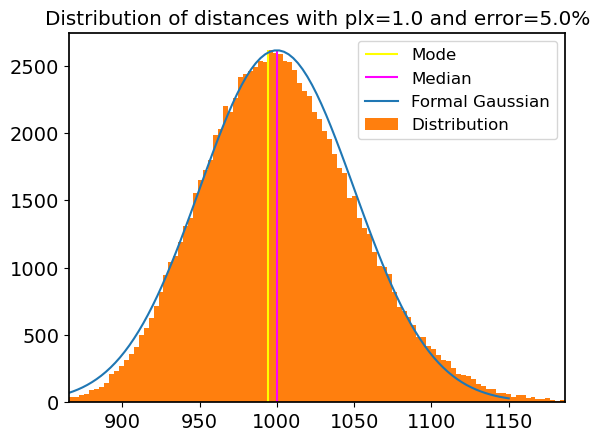

In [13]:
# borrowed from https://www.eso.org/~hboffin/Teaching/gaia_plx-2.html

def plotdis(rel_err):
    plx = 1. # in mas; this value doesn't really matter, so we can keep as such
    print(f'Parallax= {plx}, with a relative error of {rel_err}%')
    
    error_plx = rel_err / 100. * plx
    test_par= np.random.normal(plx,error_plx,100000)   # Compute a distribution of parallaxes
    test_dis = 1000./test_par                          # Distances is 1000 / parallax in pc
    test_dis = test_dis [test_dis > 0.]                # Remove the non-physical negative distances

    #print the miminum and maximum distances 
    print ("Distances vary between ",np.round(test_dis.min(),1),"and",np.round(test_dis.max(),1)," pc")

    # Compare to a Gaussian distribution of distances, centred on 1/plx 
    # and with an error given by  
    # error_dis = error_plx / plx**2. 
    dis = 1./plx
    error_dis = error_plx *dis**2. 
    
    # this is in kpc, so multiply by 1000.
    dis, error_dis = 1000.*dis, 1000.*error_dis
    
    xdis = np.linspace(-3.*error_dis,3.*error_dis,100)
    ydis= np.exp(-0.5*(xdis/error_dis)**2)
    
    
    #Compute the histogramme of distances
    bin0 = np.percentile(test_dis,.1)
    bin1 = np.percentile(test_dis,99.9)
    if rel_err > 20:
        bin0 = 0.
        bin1 = 3000./plx
    
    z, bin = np.histogram(test_dis,bins=100,range=(bin0,bin1)) #dis-3.*error_dis,dis+5.*error_dis))
    mo = bin[np.argmax(z)]   # compute the maximum of the histogram, i.e. the mode
    plt.vlines(mo,0,z.max(),color='yellow',label='Mode') 
    med = np.percentile(test_dis,50)   # the median value
    plt.vlines(med,0,z.max(),color='magenta',label='Median')
    
    ydis = ydis * z.max()
    plt.plot(xdis+dis,ydis, label='Formal Gaussian')
    
    plt.hist(test_dis,bins=bin,label='Distribution')
    print("Formal distance: ",np.round(dis,0),"+/-",error_dis," pc")
    print("Mean distance: ",np.round(np.mean(test_dis),0),"+/-",np.round(test_dis.std(),0)," pc")
    print ("Median of distance distribution: ",np.round(med,0)," pc")
    print ("Mode of distance distribution: ",np.round(mo,0)," pc")
    
    plt.xlim(bin0,bin1)
    plt.title(f'Distribution of distances with plx={plx} and error={rel_err}%')
    plt.legend();
    #print('------------------------------------------')

relative_error_plx = 1./20. * 100.  # in percents
plotdis(relative_error_plx)

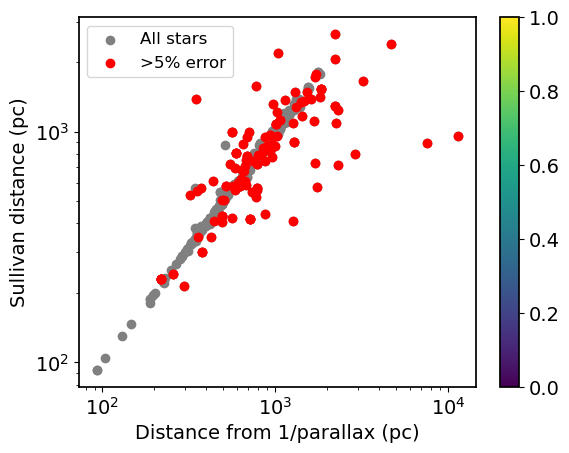

In [14]:
plt.scatter(binary_db['distance'], binary_db['distance_extra'], c='gray', label='All stars')
plt.scatter(binary_db['distance'][binary_db['parallax_over_error']<20], 
            binary_db['distance_extra'][binary_db['parallax_over_error']<20],
           c='r', label=">5% error")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance from 1/parallax (pc)')
plt.ylabel('Sullivan distance (pc)')
plt.legend()
plt.colorbar()

In [15]:
# replace where parallax error > 5% or not available at all!
replace = (binary_db['parallax_over_error'] < 20) | (~np.isfinite(binary_db['distance']))
binary_db.loc[replace, 'distance'] = binary_db['distance_extra'][replace]

binary_db['SepAU'] = binary_db['distance']*binary_db['Sep']

binary_db.to_pickle('tables/kendall+kepler.pkl')

# Assessing the compiled catalogs

Making sure things look right

### Make my catalogs

In [20]:
# read in Kendall's catalog, xmatched to all the stuff from Kepler that I need
with open('tables/kendall+kepler.pkl', 'rb') as file:
       db = pickle.load(file)

# read in my kois table
with open('tables/kois+gaia.pkl', 'rb') as file:
        kois = pd.read_pickle(file)

# add koi_impact from the vot file
kois['koi_impact'] = Table.read('tables/nexscikois_2025.05.12_09.55.50.vot').to_pandas()['koi_impact']

# build a KOI planet name from KOIpl in db so we can join to kois
# e.g. 42.009998 -> K00042.01

def format_koi_pl(value):
    if not np.isfinite(value):
        return np.nan
    whole = int(np.floor(value + 1e-6))
    frac = int(np.round((value - whole) * 100))
    if frac == 100:
        whole += 1
        frac = 0
    return f'K{whole:05d}.{frac:02d}'

if 'kepoi_name' not in db.columns:
    db['kepoi_name'] = db['KOIpl'].apply(format_koi_pl)

# add koi_impact to db by matching on the formatted planet identifier
# this is more robust for Sullivan-style KOIpl values than joining on KOI alone
db = db.merge(kois[['kepoi_name', 'koi_impact']], on='kepoi_name', how='left')


### Radius distribution of all KOIs (less the binaries)

Need the filtering on errors in order to see the radius gap.

In [ ]:
# trying to confirm this matches Sullivan's
# seems good, prob a bit dif b/c using different planet param database


good = (db['e_Rpkep']/db['Rpkep'] < 0.15) & (db['koi_period']<100)
close = db['SepAU']<100
fpc = db['distance']<500

plt.scatter(db['SepAU'][good], db['Rpkep'][good], s=100)
plt.scatter(db['SepAU'][good & fpc], db['Rpkep'][good & fpc])
plt.scatter(db['SepAU'][good & close], db['Rpkep'][good & close])
plt.ylim(0.4,4.1)
plt.xlim(3, 4000)
plt.xscale('log')
plt.xlabel('Binary sep (AU)')
plt.ylabel('Rp (Earth rad)')

(0.0, 1.1)

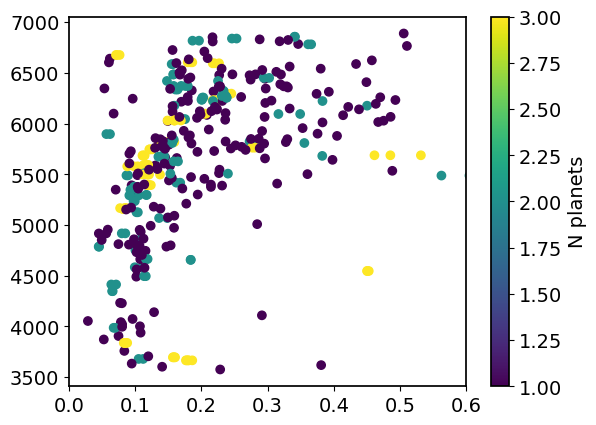

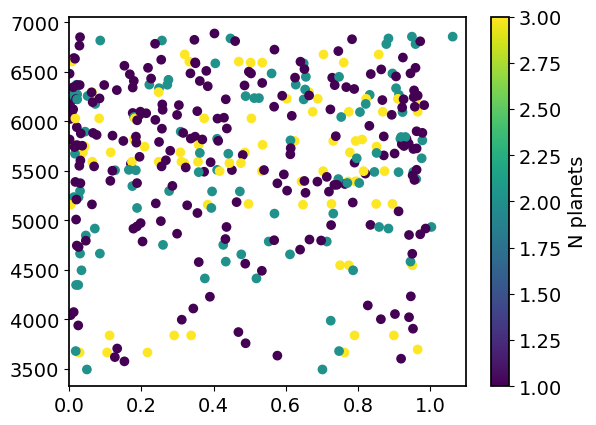

In [73]:
plt.scatter(db['e_Rppri']/db['Rppri'], db['Teff1'], c=db['n_planets'], vmax=3)
plt.colorbar(label='N planets')
plt.xlim(0,0.6)

plt.figure()
plt.scatter(db['impact'], db['Teff1'], c=db['n_planets'], vmax=3)
plt.colorbar(label='N planets')
plt.xlim(0,1.1)

In [99]:
# Histogram of impact parameter by system multiplicity
kois['impact'] = kois['koi_impact']
db['impact'] = db['koi_impact']

kois['n_planets'] = kois.groupby('KOI').KOI.transform('size')
db['n_planets'] = db.groupby('KOI').KOI.transform('size')

close = (db['SepAU'] < 100.) & (db['koi_period'] < 100) & (db['distance'] < 500) &\
(db['Teff1'] > 4700) & (db['Teff1'] < 6500)  & \
(db['KOIpl']).notnull()

multiplicity_groups = [
    (lambda df: df['n_planets'] == 1, '1 planet'),
    (lambda df: df['n_planets'] == 2, '2 planets'),
    (lambda df: df['n_planets'] >= 3, '3+ planets'),
]

    
def planet_fraction_by_multiplicity(df, star_col='KOI'):
    planet_counts = df.groupby(star_col).size().reset_index(name='n_planets')
    if len(df) == 0:
        return {}
    multiplicity_counts = planet_counts['n_planets'].value_counts().sort_index()
    total_systems = len(planet_counts)
    return {
        n: {
            'systems': count,
            'planets': int(n * count),
            'fraction_of_systems': float(count) / total_systems,
        }
        for n, count in multiplicity_counts.items()
    }

for df, label in [(kois, 'KOIs'), (db[close], 'Binaries close')]:
    sel = df
    print(f"\n{label} planets:")
    fractions = planet_fraction_by_multiplicity(sel)
    for n, stats in fractions.items():
        print(f"    n={n}: systems={stats['systems']}, planets={stats['planets']}, frac_systems={stats['fraction_of_systems']:.3f}")




KOIs planets:
    n=1: systems=7276, planets=7276, frac_systems=0.886
    n=2: systems=661, planets=1322, frac_systems=0.080
    n=3: systems=179, planets=537, frac_systems=0.022
    n=4: systems=68, planets=272, frac_systems=0.008
    n=5: systems=25, planets=125, frac_systems=0.003
    n=6: systems=3, planets=18, frac_systems=0.000
    n=7: systems=2, planets=14, frac_systems=0.000

Binaries close planets:
    n=1: systems=13, planets=13, frac_systems=0.722
    n=2: systems=3, planets=6, frac_systems=0.167
    n=3: systems=1, planets=3, frac_systems=0.056
    n=5: systems=1, planets=5, frac_systems=0.056
